# TF, C15, and C25 Informed-Guesser Sensitivity

For TF questions, if the probability of answering correctly is `p_TF`, then the score follows `2 * Binomial(70, p_TF)`. For C15 questions, if the probability of choosing the correct answer is `p_15`, then the score follows `10 * Binomial(15, p_15)`. For C25 questions, the score is calculated by enumerating the five statement judgments and applying the two-choice selection rule.


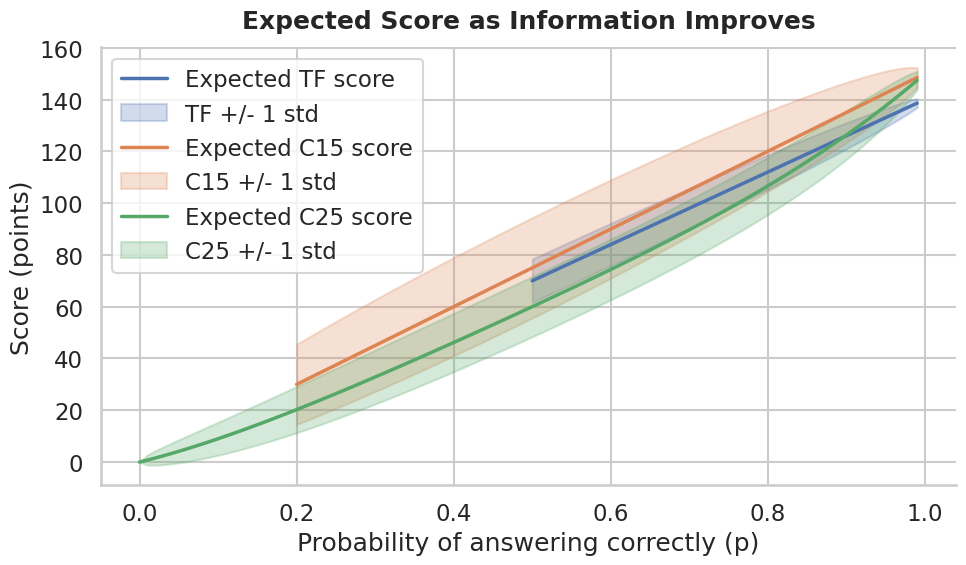

In [1]:
from itertools import combinations, product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def c25_single_question_pmf(p):
    true_statements = {0, 1}
    score_probs = {0: 0.0, 5: 0.0, 10: 0.0}

    for judged_true_bits in product([False, True], repeat=5):
        judged_true = {i for i, bit in enumerate(judged_true_bits) if bit}
        judged_false = set(range(5)) - judged_true

        prob = 1.0
        for i, bit in enumerate(judged_true_bits):
            actual_true = i in true_statements
            prob *= p if bit == actual_true else 1 - p

        if len(judged_true) < 2:
            selected_sets = [
                judged_true | set(extra)
                for extra in combinations(judged_false, 2 - len(judged_true))
            ]
        else:
            selected_sets = [set(choice) for choice in combinations(judged_true, 2)]

        for selected in selected_sets:
            n_correct = len(selected & true_statements)
            score_probs[5 * n_correct] += prob / len(selected_sets)

    return score_probs


def c25_mean_std(p):
    score_probs = c25_single_question_pmf(p)
    mean_one = sum(score * prob for score, prob in score_probs.items())
    second_moment_one = sum(score**2 * prob for score, prob in score_probs.items())
    var_one = second_moment_one - mean_one**2
    return 15 * mean_one, np.sqrt(15 * var_one)


n_tf = 70
points_per_tf = 2
p_tf = np.arange(0.5, 1, 0.01)

n_c15 = 15
points_per_c15 = 10
p_15 = np.arange(0.2, 1, 0.01)

p_25 = np.arange(0., 1, 0.01)

mean_tf = n_tf * p_tf * points_per_tf
std_tf = points_per_tf * np.sqrt(n_tf * p_tf * (1 - p_tf))

mean_c15 = n_c15 * p_15 * points_per_c15
std_c15 = points_per_c15 * np.sqrt(n_c15 * p_15 * (1 - p_15))

mean_c25 = np.array([c25_mean_std(p)[0] for p in p_25])
std_c25 = np.array([c25_mean_std(p)[1] for p in p_25])

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(p_tf, mean_tf, color="#4C72B0", linewidth=2.5, label="Expected TF score")
ax.fill_between(
    p_tf,
    mean_tf - std_tf,
    mean_tf + std_tf,
    color="#4C72B0",
    alpha=0.25,
    label="TF +/- 1 std",
)

ax.plot(p_15, mean_c15, color="#DD8452", linewidth=2.5, label="Expected C15 score")
ax.fill_between(
    p_15,
    mean_c15 - std_c15,
    mean_c15 + std_c15,
    color="#DD8452",
    alpha=0.25,
    label="C15 +/- 1 std",
)

ax.plot(p_25, mean_c25, color="#55A868", linewidth=2.5, label="Expected C25 score")
ax.fill_between(
    p_25,
    mean_c25 - std_c25,
    mean_c25 + std_c25,
    color="#55A868",
    alpha=0.25,
    label="C25 +/- 1 std",
)

#ax.axvline(0.5, color="black", linestyle="--", linewidth=1.8, label="Random guesser")
ax.set_title("Expected Score as Information Improves", weight="bold", pad=14)
ax.set_xlabel("Probability of answering correctly (p)")
ax.set_ylabel("Score (points)")

# ax.set_ylim(0, n_tf * points_per_tf)
ax.legend(frameon=True, loc="upper left")
sns.despine()
fig.tight_layout()

output_path = Path("../images/tf_c15_c25_informed_guesser_sensitivity.png")
fig.savefig(output_path, dpi=220)
plt.show()


In [ ]:
from itertools import combinations, product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def c25_selected_sets(judged_true):
    judged_true = set(judged_true)
    judged_false = set(range(5)) - judged_true
    if len(judged_true) < 2:
        selected_sets = [
            judged_true | set(extra)
            for extra in combinations(judged_false, 2 - len(judged_true))
        ]
    else:
        selected_sets = [set(choice) for choice in combinations(judged_true, 2)]
    return selected_sets


def c25_score(selected):
    true_statements = {0, 1}
    return 5 * len(set(selected) & true_statements)


def c25_gain_mean_std(p, step=0.01):
    true_statements = {0, 1}
    p_next = min(p + step, 1.0)
    dp = p_next - p

    gain_probs = {}

    # State per statement:
    # 0 = already judged correctly at p
    # 1 = wrong at p, corrected by p + step
    # 2 = still wrong at p + step
    state_probs = [p, dp, 1 - p_next]

    for states in product([0, 1, 2], repeat=5):
        prob = np.prod([state_probs[s] for s in states])
        if prob == 0:
            continue

        judged_true_before = set()
        judged_true_after = set()
        for i, state in enumerate(states):
            actual_true = i in true_statements
            correct_before = state == 0
            correct_after = state in {0, 1}

            before_judgment_true = actual_true if correct_before else not actual_true
            after_judgment_true = actual_true if correct_after else not actual_true

            if before_judgment_true:
                judged_true_before.add(i)
            if after_judgment_true:
                judged_true_after.add(i)

        before_sets = c25_selected_sets(judged_true_before)
        after_sets = c25_selected_sets(judged_true_after)

        for before_selected in before_sets:
            before_score = c25_score(before_selected)
            for after_selected in after_sets:
                after_score = c25_score(after_selected)
                gain = after_score - before_score
                gain_probs[gain] = gain_probs.get(gain, 0.0) + prob / (len(before_sets) * len(after_sets))

    mean_one = sum(gain * prob for gain, prob in gain_probs.items())
    second_moment_one = sum(gain**2 * prob for gain, prob in gain_probs.items())
    var_one = second_moment_one - mean_one**2
    return 15 * mean_one, np.sqrt(15 * var_one)


def bernoulli_gain_mean_std(n, points, p, step=0.01):
    p_next = min(p + step, 1.0)
    dp = p_next - p
    mean = n * points * dp
    std = points * np.sqrt(n * dp * (1 - dp))
    return mean, std


step = 0.01
p_tf = np.arange(0.5, 1, step)
p_15 = np.arange(0.2, 1, step)
p_25 = np.arange(0.0, 1, step)

series = {
    "TF": (p_tf, lambda p: bernoulli_gain_mean_std(70, 2, p, step), "#4C72B0"),
    "C15": (p_15, lambda p: bernoulli_gain_mean_std(15, 10, p, step), "#DD8452"),
    "C25": (p_25, lambda p: c25_gain_mean_std(p, step), "#55A868"),
}

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))

for name, (p_grid, gain_fn, color) in series.items():
    values = np.array([gain_fn(p) for p in p_grid])
    mean_gain = values[:, 0]
    ax.plot(p_grid, mean_gain, color=color, linewidth=2.5, label=name)

ax.axhline(0, color="black", linewidth=1.0, alpha=0.5)
ax.set_title("Point Gain from a 1% Improvement in p", weight="bold", pad=14)
ax.set_xlabel("Current probability of answering correctly (p)")
ax.set_ylabel("Expected score increase from p + 0.01")
ax.legend(frameon=True, loc="upper right")
sns.despine()
fig.tight_layout()

output_path = Path("../images/question_type_point_sensitivity.png")
fig.savefig(output_path, dpi=220)
plt.show()
